In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
df = pd.read_csv(PROJECT_ROOT / "artifacts" / "clean_data.csv")

TARGET = "CO2 uptake (mmol/g)"
FEATURES = [c for c in df.columns if c not in ("row_id", "split", TARGET)]

train = df[df["split"] == "train"]
val   = df[df["split"] == "validation"]
dev   = df[df["split"] != "test"]          # train + validation, used for CV later

print(len(train), len(val), len(dev))

336 84 420


In [2]:
print(train["Temp (°C)"].value_counts())
print(train["Pressure (bar)"].value_counts().head(6))

Temp (°C)
25    241
0      94
30      1
Name: count, dtype: int64
Pressure (bar)
1.000000    264
0.150000     45
1.013250      9
1.013000      8
1.013247      7
0.100000      2
Name: count, dtype: int64


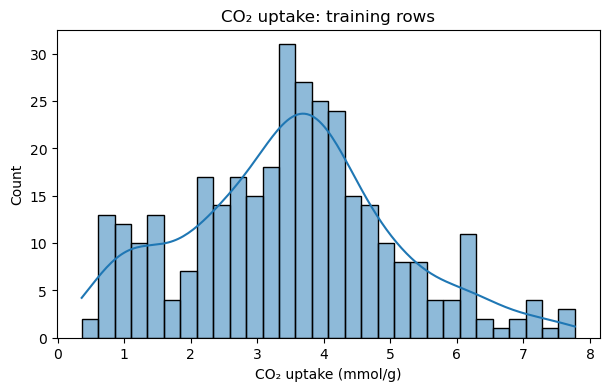

In [3]:
plt.figure(figsize=(7, 4))
sns.histplot(train[TARGET], bins=30, kde=True)
plt.xlabel("CO₂ uptake (mmol/g)")
plt.title("CO₂ uptake: training rows")
plt.show()

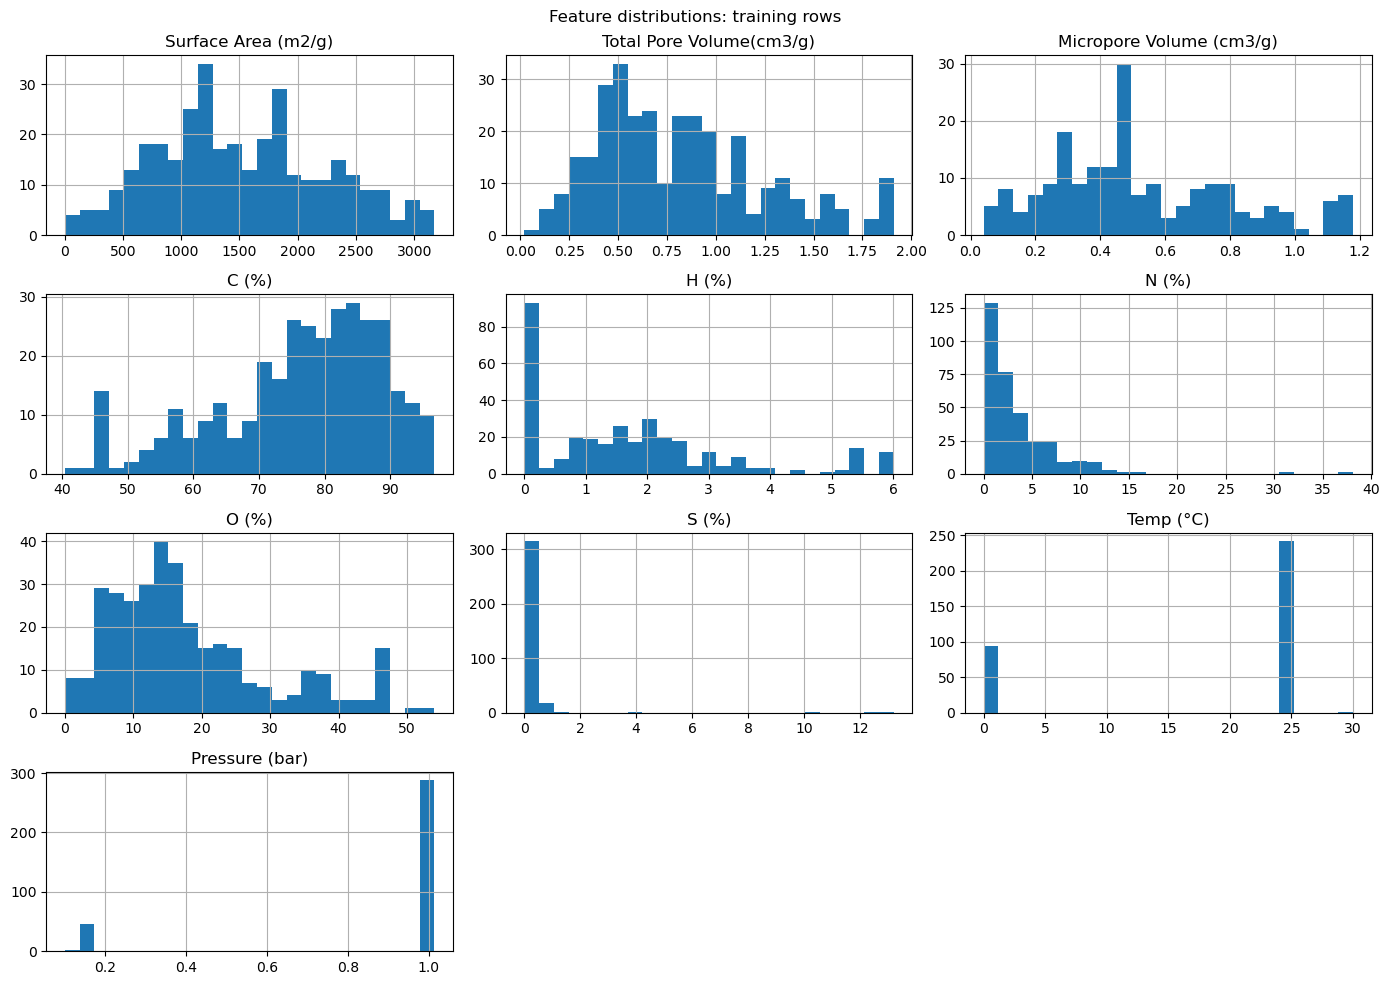

In [4]:
train[FEATURES].hist(figsize=(14, 10), bins=25)
plt.suptitle("Feature distributions: training rows")
plt.tight_layout()
plt.show()

Pressure (bar)              0.60
Temp (°C)                  -0.54
Surface Area (m2/g)         0.27
Total Pore Volume(cm3/g)    0.18
N (%)                       0.18
Micropore Volume (cm3/g)    0.15
C (%)                      -0.07
H (%)                       0.04
O (%)                       0.03
S (%)                       0.02
Name: CO2 uptake (mmol/g), dtype: float64


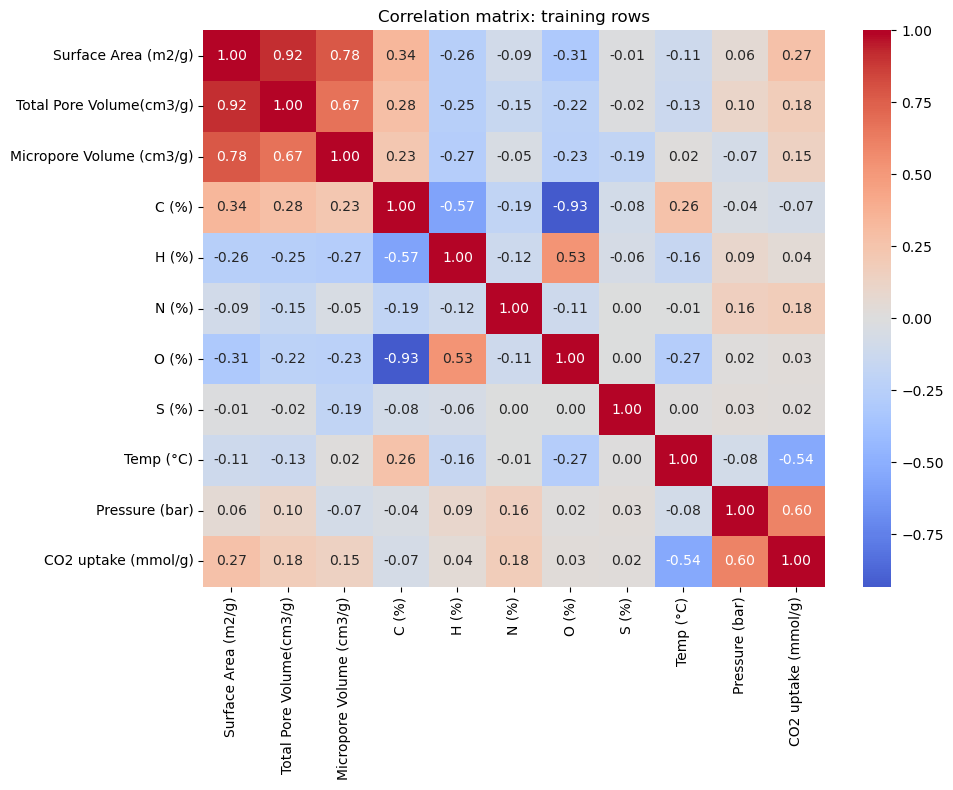

In [5]:
corr = train[FEATURES + [TARGET]].corr()

print(corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).round(2))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix: training rows")
plt.tight_layout()
plt.show()

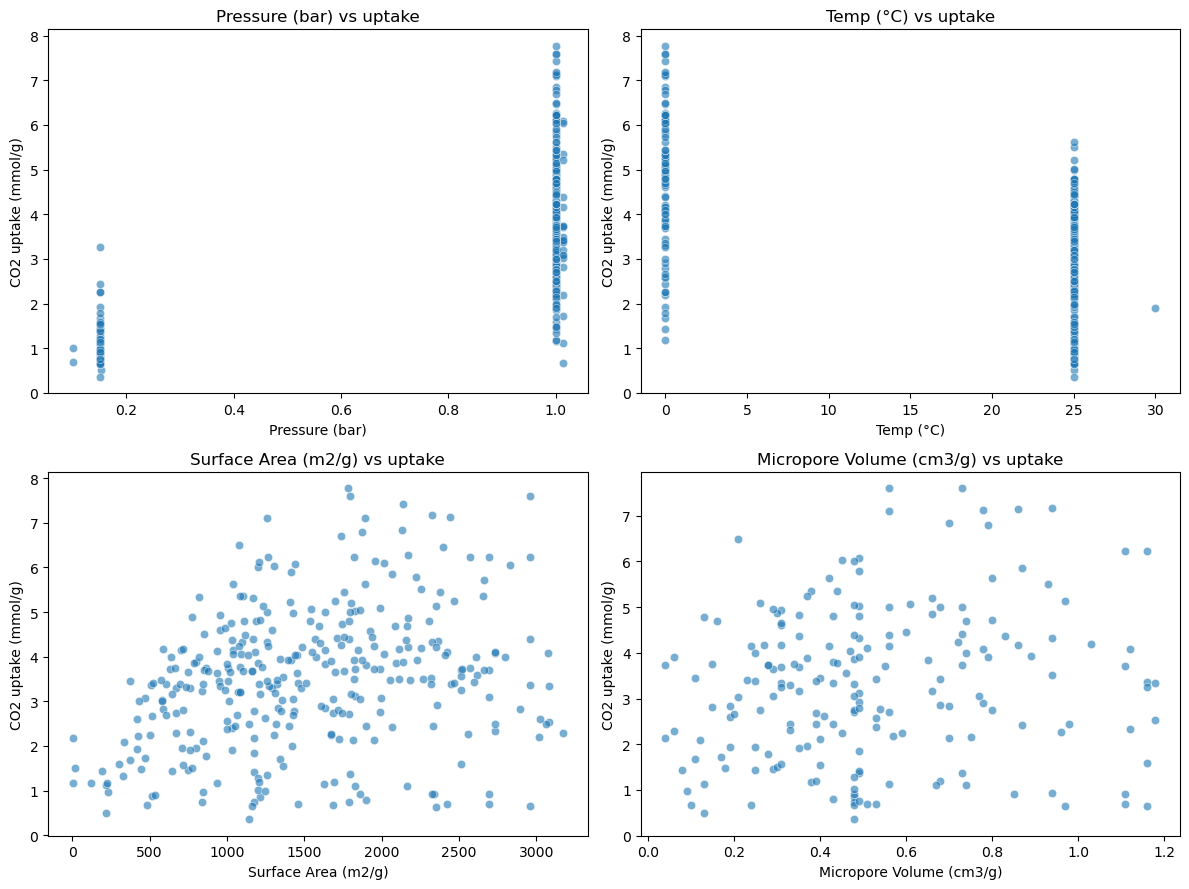

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.flat, ["Pressure (bar)", "Temp (°C)", "Surface Area (m2/g)", "Micropore Volume (cm3/g)"]):
    sns.scatterplot(data=train, x=col, y=TARGET, ax=ax, alpha=0.6)
    ax.set_title(f"{col} vs uptake")
plt.tight_layout()
plt.show()

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def score(y_true, y_pred):
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":   r2_score(y_true, y_pred),
    }

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge

models = {
    "Dummy": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyRegressor(strategy="mean")),
    ]),
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ]),
}

val_results = []
for name, model in models.items():
    model.fit(train[FEATURES], train[TARGET])           # learn from TRAIN only
    preds = model.predict(val[FEATURES])                # guess on VALIDATION
    val_results.append({"Model": name, **score(val[TARGET], preds)})

pd.DataFrame(val_results).round(3)

,Model,MAE,RMSE,R2
0,Dummy,1.236,1.528,-0.029
1,Ridge,0.663,0.901,0.642


In [9]:
from sklearn.model_selection import KFold, cross_validate

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, model in models.items():
    out = cross_validate(model, dev[FEATURES], dev[TARGET], cv=cv,
                         scoring=("neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"))
    rmse = -out["test_neg_root_mean_squared_error"]
    cv_results.append({
        "Model": name,
        "CV MAE":   -out["test_neg_mean_absolute_error"].mean(),
        "CV RMSE":  rmse.mean(),
        "RMSE std": rmse.std(),
        "CV R2":    out["test_r2"].mean(),
    })

cv_table = pd.DataFrame(cv_results).round(3)
cv_table

,Model,CV MAE,CV RMSE,RMSE std,CV R2
0,Dummy,1.216,1.545,0.068,-0.007
1,Ridge,0.688,0.903,0.093,0.652


In [10]:
results_dir = PROJECT_ROOT / "results"
pd.DataFrame(val_results).round(4).to_csv(results_dir / "baseline_validation.csv", index=False)
cv_table.to_csv(results_dir / "baseline_cv.csv", index=False)
print("Saved.")

Saved.
